# Modeling a Pincell
In this lecture, we'll demonstrate the basic features of the Python API for constructing input files and running OpenMC. In it, we will show how to create a basic reflective pincell model that is equivalent to modeling an infinite array of fuel pins in a pressurized water reactor. We highly recommend having a copy of the [Python API reference documentation](https://docs.openmc.org/en/stable/pythonapi/index.html) open in another browser tab that you can refer to.

<img src="pincell.png" alt="drawing" width="250"/>

For this example, we'll create a simple pincell that is composed of:
- UO<sub>2</sub> with 3.5 weight% enriched in U-235 at 11 g/cm<sup>3</sup>
- zirconium clad at 6.5 g/cm<sup>3</sup>
- H<sub>2</sub>O moderator at 1.0 g/cm<sup>3</sup>

The dimensions of our fuel pin will be as follows:
- Fuel outer radius = 0.46955 cm
- Clad inner radius = 0.47910 cm
- Clad outer radius = 0.54640 cm
- Fuel pin pitch = 1.44270 cm
- Pin height = 300.0 cm

In [57]:
import openmc
import matplotlib.pyplot as plt
import numpy as np

## Basics of Jupyter Notebook

You are working within a Jupyter notebook. Some common commands which will be useful:
- To execute a cell: `Shift+Enter`
- To insert a cell above or below: `Esc+a`, `Esc+b`

## Naming Conventions

Before we start working with OpenMC's Python API, it's helpful to understand the naming convention of objects so that you can conceptualize what is a function, what is a class, etc. OpenMC's Python interface follows the same naming convention that is adopted by many/most Python projects:

- Module names are `lowercase`
- Classes are `CamelCase`
- Functions and class attributes/variables are `lowercase_with_underscores`

To give a few specific examples:

- `openmc.deplete` is the depletion _module_
- `openmc.run` is a _function_
- `openmc.Material` is a _class_
- `openmc.StatePoint` is a _class_

## Setting Attributes

When building OpenMC models, we will work with many different classes. Each class typically has _attributes_, a variable belonging to the class. When creating a class, you can often set those attributes directly when you instantiate the object, like this:

In [15]:
my_cell = openmc.Cell(name="box")

Or, you can assign values to attributes after you have already created the object. For example, the following is equivalent to the above:

In [16]:
my_other_cell = openmc.Cell()
my_other_cell.name = "box2"

You can generally also mix-and-match, setting some attributes when you instantiate the object, and others at a later point.

In [17]:
new_cell = openmc.Cell(name="box3")
new_cell.temperature = 500


## How to Get Help/Learn More

When building OpenMC models, we recommend having a copy of the Python API documentation (linked earlier) open. You can also query information about classes and methods directly from Jupyter. For example, we can use `help` to get documentation on all of the valid attributes for functions and classes.

In [18]:
help(openmc.Cell)

Help on class Cell in module openmc.cell:

class Cell(openmc.mixin.IDManagerMixin)
 |  Cell(cell_id=None, name='', fill=None, region=None)
 |  
 |  A region of space defined as the intersection of half-space created by
 |  quadric surfaces.
 |  
 |  Parameters
 |  ----------
 |  cell_id : int, optional
 |      Unique identifier for the cell. If not specified, an identifier will
 |      automatically be assigned.
 |  name : str, optional
 |      Name of the cell. If not specified, the name is the empty string.
 |  fill : openmc.Material or openmc.UniverseBase or openmc.Lattice or None or iterable of openmc.Material, optional
 |      Indicates what the region of space is filled with
 |  region : openmc.Region, optional
 |      Region of space that is assigned to the cell.
 |  
 |  Attributes
 |  ----------
 |  id : int
 |      Unique identifier for the cell
 |  name : str
 |      Name of the cell
 |  fill : openmc.Material or openmc.UniverseBase or openmc.Lattice or None or iterable of o

Attributes which have a default value will appear as `<attribute>=<the default value>` in the class/function definition. For example, in the above we see that the default name for a cell is the empty string, `''`.

For classes, all of the member functions you can access will then be defined further down, with their associated documentation. To see documentation for just one specific function, you can use syntax like:

In [19]:
my_cell = openmc.Cell()
help(my_cell.clone)

Help on method clone in module openmc.cell:

clone(clone_materials=True, clone_regions=True, memo=None) method of openmc.cell.Cell instance
    Create a copy of this cell with a new unique ID, and clones
    the cell's region and fill.
    
    Parameters
    ----------
    clone_materials : bool
        Whether to create separate copies of the materials filling cells
        contained in this cell, or the material filling this cell.
    clone_regions : bool
        Whether to create separate copies of the regions bounding cells
        contained in this cell, and the region bounding this cell.
    memo : dict or None
        A nested dictionary of previously cloned objects. This parameter
        is used internally and should not be specified by the user.
    
    Returns
    -------
    clone : openmc.Cell
        The clone of this cell



In [20]:
print(my_cell)

Cell
	ID             =	7
	Name           =	
	Fill           =	None
	Region         =	None
	Rotation       =	None
	Translation    =	None
	Volume         =	None



In order to quickly see all of the member functions on a class, press `Tab` to perform tab-completion to view a drop-down list on all the options available to you. You can then do `Shift+Tab` to see the documentation for each function inline.

In [21]:
#my_cell.

## OpenMC Model

The OpenMC `Model` class houses all of the pieces of a Monte Carlo simulation. We will assemble our pincell by progressively adding to a model, and then run that model.

In [22]:
model = openmc.Model()

### The `cross_sections.xml` file

The `cross_sections.xml` tells OpenMC where it can find nuclide cross sections and $S(\alpha,\beta)$ tables. Let's have a look at what's inside this file:

In [23]:
!cat $OPENMC_CROSS_SECTIONS | head -n 10
print('    ...')
!cat $OPENMC_CROSS_SECTIONS | tail -n 10

<?xml version='1.0' encoding='utf-8'?>
<cross_sections>
  <library materials="H1" path="neutron/H1.h5" type="neutron" />
  <library materials="H2" path="neutron/H2.h5" type="neutron" />
  <library materials="H3" path="neutron/H3.h5" type="neutron" />
  <library materials="He3" path="neutron/He3.h5" type="neutron" />
  <library materials="He4" path="neutron/He4.h5" type="neutron" />
  <library materials="Li6" path="neutron/Li6.h5" type="neutron" />
  <library materials="Li7" path="neutron/Li7.h5" type="neutron" />
  <library materials="Be7" path="neutron/Be7.h5" type="neutron" />
    ...
  <library materials="Cf253" path="wmp/098253.h5" type="wmp" />
  <library materials="Cf254" path="wmp/098254.h5" type="wmp" />
  <library materials="Es251" path="wmp/099251.h5" type="wmp" />
  <library materials="Es252" path="wmp/099252.h5" type="wmp" />
  <library materials="Es253" path="wmp/099253.h5" type="wmp" />
  <library materials="Es254" path="wmp/099254.h5" type="wmp" />
  <library materials="

## Defining Materials

Materials in OpenMC are defined as a set of nuclides with specified atom/weight fractions. To begin, we will create a material by making an instance of the `Material` class.

In [24]:
zirconium = openmc.Material(1, "zirconium")
print(zirconium)

Material
	ID             =	1
	Name           =	zirconium
	Temperature    =	None
	Density        =	None [sum]
	Volume         =	None [cm^3]
	Depletable     =	False
	S(a,b) Tables  
	Nuclides       



/Users/anovak/projects/openmc/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=1.
  warn(msg, IDWarning)


The `Material` class has a method `add_element()` whose first argument is the name of the nuclide and second argument is the atom or weight fraction. We see that by default it assumes we want an atom fraction.

In [25]:
#zirconium.add_element

In [26]:
zirconium.add_element('Zr', 1.0)
zirconium.set_density('g/cm3', 6.5)

In [27]:
print(zirconium)

Material
	ID             =	1
	Name           =	zirconium
	Temperature    =	None
	Density        =	6.5 [g/cm3]
	Volume         =	None [cm^3]
	Depletable     =	False
	S(a,b) Tables  
	Nuclides       
	Zr90           =	0.5145       [ao]
	Zr91           =	0.1122       [ao]
	Zr92           =	0.1715       [ao]
	Zr94           =	0.1738       [ao]
	Zr96           =	0.028        [ao]



We can see that OpenMC automatically inserted the natural abundances of the zirconium isotopes for us! How convenient! 

Let's now build our fuel material. For sake of illustration, let's suppose that we had O-16, but not natural oxygen in our fuel. Also note that OpenMC has a convenient feature to set the nuclide concentrations for weight percent enrichments in U-235.

In [28]:
# Add nuclides to uo2
uo2 = openmc.Material(name="uo2")
uo2.add_element('U', 1.0, enrichment=3.5)
uo2.add_nuclide('O16', 2.0)
uo2.set_density('g/cm3', 10.0)

With UO2 finished, let's now create materials for the coolant.

In [29]:
water = openmc.Material(name="water")
water.add_element('H', 2.0)
water.add_nuclide('O16', 1.0)
water.set_density('g/cm3', 1.0)

An astute observer might now point out that this water material we just created will only use free-atom cross sections. We need to tell it to use an $S(\alpha,\beta)$ table so that the bound atom cross section is used at thermal energies. To do this, there's an `add_s_alpha_beta()` method.

In [30]:
water.add_s_alpha_beta('c_H_in_H2O')

We are done with our materials -- now we just need to register them in our model.

In [31]:
model.materials = openmc.Materials([uo2, zirconium, water])
print(model.materials)

[Material
	ID             =	4
	Name           =	uo2
	Temperature    =	None
	Density        =	10.0 [g/cm3]
	Volume         =	None [cm^3]
	Depletable     =	True
	S(a,b) Tables  
	Nuclides       
	U234           =	0.0003166930253944235 [ao]
	U235           =	0.03543164439454172 [ao]
	U238           =	0.964089368630351 [ao]
	U236           =	0.00016229394971280895 [ao]
	O16            =	2.0          [ao]
, Material
	ID             =	1
	Name           =	zirconium
	Temperature    =	None
	Density        =	6.5 [g/cm3]
	Volume         =	None [cm^3]
	Depletable     =	False
	S(a,b) Tables  
	Nuclides       
	Zr90           =	0.5145       [ao]
	Zr91           =	0.1122       [ao]
	Zr92           =	0.1715       [ao]
	Zr94           =	0.1738       [ao]
	Zr96           =	0.028        [ao]
, Material
	ID             =	5
	Name           =	water
	Temperature    =	None
	Density        =	1.0 [g/cm3]
	Volume         =	None [cm^3]
	Depletable     =	False
	S(a,b) Tables  
	S(a,b)         =	('c_H_in_H2O', 1.0)

## Defining Geometry

We now need to define the geometry. One way to do so is to use constructive solid geometry (CSG), also known as combinatorial geometry. The object that allows us to assign a material to a region of space is called a `Cell`. There are four stages in building a cell:

#### Surfaces
In order to define a region that we can assign to a cell, we must first define surfaces which bound the region. A *surface* is a locus of zeros of a function of Cartesian coordinates $x$, $y$, and $z$, e.g.

- A plane perpendicular to the x axis: $x - x_0 = 0$
- A cylinder parallel to the z axis: $(x - x_0)^2 + (y - y_0)^2 - R^2 = 0$
- A sphere: $(x - x_0)^2 + (y - y_0)^2 + (z - z_0)^2 - R^2 = 0$

The full [list of available surfaces](https://docs.openmc.org/en/stable/pythonapi/base.html#building-geometry) is as follows.

Planes:

- `openmc.Plane` — An arbitrary plane of the form $Ax + By + Cz = D$
- `openmc.XPlane` — A plane perpendicular to the x axis of the form $x - x_0 = 0$
- `openmc.YPlane` — A plane perpendicular to the y axis of the form $y - y_0 = 0$
- `openmc.ZPlane` — A plane perpendicular to the z axis of the form $z - z_0 = 0$

Quadrics:

- `openmc.XCylinder` — An infinite cylinder whose length is parallel to the x-axis of the form $(y - y_0)^2 + (z - z_0)^2 = r^2$
- `openmc.YCylinder` — An infinite cylinder whose length is parallel to the x-axis of the form $(x - x_0)^2 + (z - z_0)^2 = r^2$
- `openmc.ZCylinder` — An infinite cylinder whose length is parallel to the x-axis of the form $(x - x_0)^2 + (y - y_0)^2 = r^2$
- `openmc.Sphere` — A sphere of the form $(x - x_0)^2 + (y - y_0)^2 + (z - z_0)^2 = r^2$
- `openmc.XCone` — A cone parallel to the x-axis of the form $(y - y_0)^2 + (z - z_0)^2 = r^2 (x - x_0)^2$
- `openmc.YCone` — A cone parallel to the y-axis of the form $(x - x_0)^2 + (z - z_0)^2 = r^2 (y - y_0)^2$
- `openmc.ZCone` — A cone parallel to the z-axis of the form $(x - x_0)^2 + (y - y_0)^2 = r^2 (z - z_0)^2$
- `openmc.Quadric` — A generic quadric surface

Torii:

- `openmc.XTorus` — A torus of the form $(x - x_0)^2/B^2 + (\sqrt{(y - y_0)^2 + (z - z_0)^2} - A)^2/C^2 - 1 = 0$
- `openmc.YTorus` — A torus of the form $(y - y_0)^2/B^2 + (\sqrt{(x - x_0)^2 + (z - z_0)^2} - A)^2/C^2 - 1 = 0$
- `openmc.ZTorus` — A torus of the form $(z - z_0)^2/B^2 + (\sqrt{(x - x_0)^2 + (y - y_0)^2} - A)^2/C^2 - 1 = 0$

#### Half-Spaces

<img src="csg_half.png" alt="drawing" width="600"/>

A surface *half-space* is the region whose points satisfy a positive or negative inequality of the surface equation. For example, for a sphere of radius one centered at the origin, the surface equation is $f(x,y,z) = x^2 + y^2 + z^2 - 1 = 0$. Thus, we say that the negative half-space of the sphere is defined as the collection of points satisfying $f(x,y,z) < 0$, which one can reason is the inside of the sphere. Conversely, the positive half-space of the sphere would correspond to all points outside of the sphere.

#### Regions
A region is then a combination of (or just one) half-spaces.

<img src="csg.png" alt="drawing" width="400"/>

#### Fills
Finally, a cell is complete once we have defined what is _filling_ the cell, which may be one of:

- material
- nothing (`None`), or vacuum/void
- universe
- lattice

In [32]:
sphere = openmc.Sphere(x0=0, y0=0, z0=0, r=1.0)

To get the negative or positive half-space, we simply need to apply the `-` or `+` unary operators, respectively.

In [33]:
inside_sphere = -sphere
outside_sphere = +sphere

Now let's see if `inside_sphere` actually contains points inside the sphere:

In [34]:
print((0,0,0) in inside_sphere, (0,0,2) in inside_sphere)
print((0,0,0) in outside_sphere, (0,0,2) in outside_sphere)

True False
False True


Everything works as expected! Now that we understand how to create half-spaces, we can create more complex volumes by combining half-spaces using Boolean operators: `&` (intersection), `|` (union), and `~` (complement):

- `&`: logical AND
- `|`: logical OR
- `~`: logical NOT

For example, let's say we want to define a region that is the top part of the sphere (all points inside the sphere that have $z > 0$.

In [35]:
z_plane = openmc.ZPlane(0)
northern_hemisphere = -sphere & +z_plane

In [36]:
cell = openmc.Cell()
cell.region = northern_hemisphere

cell.fill = water

### Universes and in-line plotting

A collection of cells is known as a universe and can be used as a repeatable unit when creating a model. Although we don't need it yet, the benefit of creating a universe is that we can visualize our geometry while we're creating it.

In [37]:
universe = openmc.Universe()
universe.add_cell(cell)

The `Universe` object has a `plot` method that will display our the universe as current constructed:

<Axes: xlabel='x [cm]', ylabel='z [cm]'>

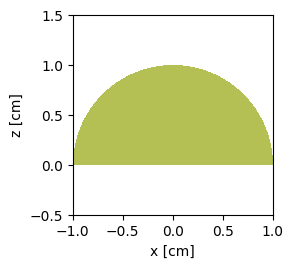

In [38]:
universe.plot(width=(2.0, 2.0), basis='xz')

### Boundary Conditions

To specify boundary conditions, you simply need to set the `Surface.boundary_type` to one of:

- `transmission` (default)
- `vacuum`
- `reflective`
- `periodic` (either rotational or translational)
- `white` (isotropic angular flux)

<img src="mc_bcs.png" alt="drawing" width="600"/>

In [39]:
northern_hemisphere.boundary_type = 'vacuum'

### Pin cell geometry

We now have enough knowledge to create our pin-cell. We need three surfaces to define the fuel and clad:

1. The outer surface of the fuel -- a cylinder parallel to the z axis
2. The inner surface of the clad -- same as above
3. The outer surface of the clad -- same as above

These three surfaces will all be instances of `openmc.ZCylinder`, each with a different radius according to the specification.

In [40]:
fuel_outer_radius = openmc.ZCylinder(r=0.46955)
clad_inner_radius = openmc.ZCylinder(r=0.47910)
clad_outer_radius = openmc.ZCylinder(r=0.54640)

With the surfaces created, we can now take advantage of the built-in operators on surfaces to create regions for the fuel, the gap, and the clad:

In [41]:
fuel_region = -fuel_outer_radius
gap_region = +fuel_outer_radius & -clad_inner_radius
clad_region = +clad_inner_radius & -clad_outer_radius

We will also create two z-planes in order to bound the geometry in the axial direction.

In [42]:
top = openmc.ZPlane(z0=150.0, boundary_type='vacuum')
bot = openmc.ZPlane(z0=-150.0, boundary_type='vacuum')
layer = +bot & -top

Now we can create corresponding cells that assign materials to these regions.

In [43]:
fuel = openmc.Cell()
fuel.fill = uo2
fuel.region = fuel_region & layer

gap = openmc.Cell()
gap.region = gap_region & layer
gap.fill = None

clad = openmc.Cell()
clad.fill = zirconium
clad.region = clad_region & layer

Finally, we need to handle the coolant outside of our fuel pin. To do this, we create x- and y-planes that bound the geometry.

In [44]:
pitch = 1.44270
left = openmc.XPlane(-pitch/2, boundary_type='reflective')
right = openmc.XPlane(pitch/2, boundary_type='reflective')
front = openmc.YPlane(-pitch/2, boundary_type='reflective')
back = openmc.YPlane(pitch/2, boundary_type='reflective')

The water region is going to be everything outside of the clad outer radius and within the box formed as the intersection of four half-spaces.

In [45]:
water_region = +left & -right & +front & -back & +clad_outer_radius & layer

moderator = openmc.Cell()
moderator.fill = water
moderator.region = water_region

The final step is to assign the cells we created to a universe and tell OpenMC that this universe is the "root" universe in our geometry.

In [46]:
root_universe = openmc.Universe(cells=(fuel, gap, clad, moderator))
model.geometry = openmc.Geometry(root_universe)

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

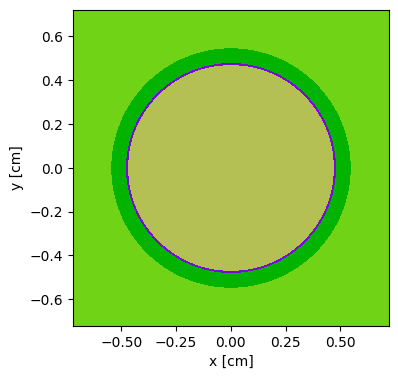

In [47]:
root_universe.plot((0, 0, 0), width=(pitch, pitch), pixels=100000)

## Starting source and settings

The Python API has a module `openmc.stats` with various univariate and multivariate probability distributions. We can use these distributions to create a starting source using the `openmc.Source` object. One can independently specify the spatial distribution (`space`), the angular distribution (`angle`), the energy distribution (`energy`), and the time distribution (`time`). For this example, we'll only specify the spatial distribution as uniform over the pincell, but only in the fissionable materials.

In [49]:
# Create a uniform source
model.settings.source = openmc.IndependentSource(space=openmc.stats.Box(
    [-pitch/2, -pitch/2, 0], [pitch/2, pitch/2, 300], only_fissionable=True))

In [51]:
model.settings.batches = 400
model.settings.inactive = 200
model.settings.particles = 1000

## Running OpenMC

Running OpenMC from Python can be done using the `model.run()` function.

In [52]:
statepoint = model.run()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

      203/1    1.39282    1.43796 +/- 0.02715
      204/1    1.44177    1.43892 +/- 0.01922
      205/1    1.42773    1.43668 +/- 0.01505
      206/1    1.35610    1.42325 +/- 0.01821
      207/1    1.44896    1.42692 +/- 0.01582
      208/1    1.48133    1.43372 +/- 0.01529
      209/1    1.47394    1.43819 +/- 0.01421
      210/1    1.47324    1.44170 +/- 0.01318
      211/1    1.43466    1.44106 +/- 0.01194
      212/1    1.46699    1.44322 +/- 0.01111
      213/1    1.36790    1.43742 +/- 0.01175
      214/1    1.44053    1.43765 +/- 0.01088
      215/1    1.49288    1.44133 +/- 0.01078
      216/1    1.32628    1.43414 +/- 0.01238
      217/1    1.42125    1.43338 +/- 0.01166
      218/1    1.41768    1.43251 +/- 0.01103
      219/1    1.42546    1.43214 +/- 0.01044
      220/1    1.33174    1.42712 +/- 0.01110
      221/1    1.44617    1.42802 +/- 0.01060
      222/1    1.49961    1.43128 +/- 0.01061
      223/1    1.55635    1.43672 +/- 0.01151
      224/1    1.37950    1.43433 

      383/1    1.37046    1.42931 +/- 0.00401
      384/1    1.46728    1.42952 +/- 0.00399
      385/1    1.35454    1.42911 +/- 0.00399
      386/1    1.44512    1.42920 +/- 0.00397
      387/1    1.37647    1.42891 +/- 0.00396
      388/1    1.40775    1.42880 +/- 0.00394
      389/1    1.47628    1.42905 +/- 0.00393
      390/1    1.39534    1.42888 +/- 0.00391
      391/1    1.39147    1.42868 +/- 0.00389
      392/1    1.39736    1.42852 +/- 0.00388
      393/1    1.50234    1.42890 +/- 0.00387
      394/1    1.40266    1.42876 +/- 0.00386
      395/1    1.43747    1.42881 +/- 0.00384
      396/1    1.32690    1.42829 +/- 0.00385
      397/1    1.42503    1.42827 +/- 0.00383
      398/1    1.50710    1.42867 +/- 0.00383
      399/1    1.45410    1.42880 +/- 0.00382
      400/1    1.46597    1.42898 +/- 0.00380
 Creating state point statepoint.400.h5...

 =======================>     TIMING STATISTICS     <=======================

 Total time for initialization     = 3.4933e+00 se

In [53]:
with openmc.StatePoint(statepoint) as sp:
  k = sp.keff.nominal_value
  k_std_dev = sp.keff.std_dev
    
print(k)
print(k_std_dev)

1.425498673036943
0.0020569045663972377


### Running in a loop

For several questions on CP3, you're asked to repeatedly run OpenMC using different setting

In [64]:
particles = [500, 1000, 2000]
k_values = []
err_values = []
for p in particles:
    model.settings.particles = p
    model.run()
    
    with openmc.StatePoint(statepoint) as sp:
        k_values.append(sp.keff.nominal_value)
        err_values.append(sp.keff.std_dev)

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

      202/1    1.38964    1.34351 +/- 0.04614
      203/1    1.29254    1.32652 +/- 0.03159
      204/1    1.47520    1.36369 +/- 0.04337
      205/1    1.41806    1.37456 +/- 0.03531
      206/1    1.38594    1.37646 +/- 0.02889
      207/1    1.38948    1.37832 +/- 0.02449
      208/1    1.48673    1.39187 +/- 0.02517
      209/1    1.47239    1.40082 +/- 0.02393
      210/1    1.32187    1.39292 +/- 0.02281
      211/1    1.34360    1.38844 +/- 0.02112
      212/1    1.50210    1.39791 +/- 0.02148
      213/1    1.54067    1.40889 +/- 0.02260
      214/1    1.37339    1.40636 +/- 0.02108
      215/1    1.46875    1.41052 +/- 0.02006
      216/1    1.43309    1.41193 +/- 0.01882
      217/1    1.43187    1.41310 +/- 0.01772
      218/1    1.37439    1.41095 +/- 0.01684
      219/1    1.42801    1.41185 +/- 0.01595
      220/1    1.31160    1.40683 +/- 0.01594
      221/1    1.38926    1.40600 +/- 0.01519
      222/1    1.32234    1.40219 +/- 0.01497
      223/1    1.40693    1.40240 

      383/1    1.37761    1.42686 +/- 0.00525
      384/1    1.37250    1.42657 +/- 0.00523
      385/1    1.39024    1.42637 +/- 0.00520
      386/1    1.35792    1.42600 +/- 0.00519
      387/1    1.41530    1.42594 +/- 0.00516
      388/1    1.38277    1.42571 +/- 0.00514
      389/1    1.41859    1.42568 +/- 0.00511
      390/1    1.44614    1.42578 +/- 0.00509
      391/1    1.48709    1.42611 +/- 0.00507
      392/1    1.47193    1.42634 +/- 0.00505
      393/1    1.47173    1.42658 +/- 0.00503
      394/1    1.68304    1.42790 +/- 0.00517
      395/1    1.34622    1.42748 +/- 0.00516
      396/1    1.41270    1.42741 +/- 0.00514
      397/1    1.38508    1.42719 +/- 0.00512
      398/1    1.45678    1.42734 +/- 0.00509
      399/1    1.50857    1.42775 +/- 0.00508
      400/1    1.44447    1.42783 +/- 0.00506
 Creating state point statepoint.400.h5...

 =======================>     TIMING STATISTICS     <=======================

 Total time for initialization     = 2.1156e+00 se

      115/1    1.48079
      116/1    1.41659
      117/1    1.44981
      118/1    1.46012
      119/1    1.43577
      120/1    1.40137
      121/1    1.40300
      122/1    1.47078
      123/1    1.34396
      124/1    1.48432
      125/1    1.42655
      126/1    1.32856
      127/1    1.35100
      128/1    1.36845
      129/1    1.45433
      130/1    1.46466
      131/1    1.46916
      132/1    1.51195
      133/1    1.38017
      134/1    1.39029
      135/1    1.42075
      136/1    1.51780
      137/1    1.32250
      138/1    1.48591
      139/1    1.33450
      140/1    1.40504
      141/1    1.43041
      142/1    1.34648
      143/1    1.45436
      144/1    1.43025
      145/1    1.43283
      146/1    1.48215
      147/1    1.39857
      148/1    1.41964
      149/1    1.52900
      150/1    1.44714
      151/1    1.49852
      152/1    1.47360
      153/1    1.44603
      154/1    1.45166
      155/1    1.43297
      156/1    1.43928
      157/1    1.44061
      158/1

      339/1    1.45921    1.42850 +/- 0.00464
      340/1    1.44939    1.42865 +/- 0.00461
      341/1    1.43236    1.42867 +/- 0.00457
      342/1    1.42648    1.42866 +/- 0.00454
      343/1    1.47196    1.42896 +/- 0.00452
      344/1    1.36258    1.42850 +/- 0.00451
      345/1    1.40314    1.42833 +/- 0.00448
      346/1    1.49214    1.42876 +/- 0.00447
      347/1    1.30482    1.42792 +/- 0.00452
      348/1    1.45801    1.42812 +/- 0.00450
      349/1    1.38086    1.42781 +/- 0.00448
      350/1    1.39453    1.42758 +/- 0.00445
      351/1    1.39526    1.42737 +/- 0.00443
      352/1    1.40276    1.42721 +/- 0.00440
      353/1    1.47290    1.42751 +/- 0.00438
      354/1    1.45925    1.42771 +/- 0.00436
      355/1    1.49753    1.42816 +/- 0.00436
      356/1    1.45358    1.42833 +/- 0.00433
      357/1    1.44044    1.42840 +/- 0.00430
      358/1    1.50134    1.42886 +/- 0.00430
      359/1    1.45462    1.42903 +/- 0.00428
      360/1    1.48811    1.42940 

       21/1    1.40779
       22/1    1.49104
       23/1    1.41660
       24/1    1.45120
       25/1    1.42486
       26/1    1.46021
       27/1    1.44044
       28/1    1.43555
       29/1    1.41779
       30/1    1.45055
       31/1    1.41036
       32/1    1.39668
       33/1    1.45251
       34/1    1.40314
       35/1    1.41046
       36/1    1.47404
       37/1    1.38549
       38/1    1.51846
       39/1    1.48502
       40/1    1.36847
       41/1    1.44893
       42/1    1.47512
       43/1    1.38484
       44/1    1.42152
       45/1    1.38225
       46/1    1.44346
       47/1    1.43676
       48/1    1.44147
       49/1    1.45896
       50/1    1.54316
       51/1    1.45383
       52/1    1.40647
       53/1    1.41872
       54/1    1.39918
       55/1    1.41226
       56/1    1.43284
       57/1    1.42437
       58/1    1.44971
       59/1    1.41896
       60/1    1.43460
       61/1    1.44892
       62/1    1.42776
       63/1    1.49435
       64/1

      291/1    1.41718    1.42464 +/- 0.00405
      292/1    1.47050    1.42514 +/- 0.00404
      293/1    1.38410    1.42469 +/- 0.00402
      294/1    1.37202    1.42413 +/- 0.00402
      295/1    1.35476    1.42340 +/- 0.00404
      296/1    1.48397    1.42403 +/- 0.00405
      297/1    1.39164    1.42370 +/- 0.00402
      298/1    1.41540    1.42362 +/- 0.00398
      299/1    1.39508    1.42333 +/- 0.00395
      300/1    1.42228    1.42332 +/- 0.00391
      301/1    1.38566    1.42294 +/- 0.00389
      302/1    1.37807    1.42250 +/- 0.00388
      303/1    1.43720    1.42265 +/- 0.00384
      304/1    1.43089    1.42273 +/- 0.00380
      305/1    1.42969    1.42279 +/- 0.00377
      306/1    1.38956    1.42248 +/- 0.00375
      307/1    1.44065    1.42265 +/- 0.00371
      308/1    1.42343    1.42266 +/- 0.00368
      309/1    1.44581    1.42287 +/- 0.00365
      310/1    1.50715    1.42364 +/- 0.00370
      311/1    1.47958    1.42414 +/- 0.00370
      312/1    1.43564    1.42424 

[500, 1000, 2000]
[1.4297242609821035, 1.4254986730369448, 1.4258848186183608]


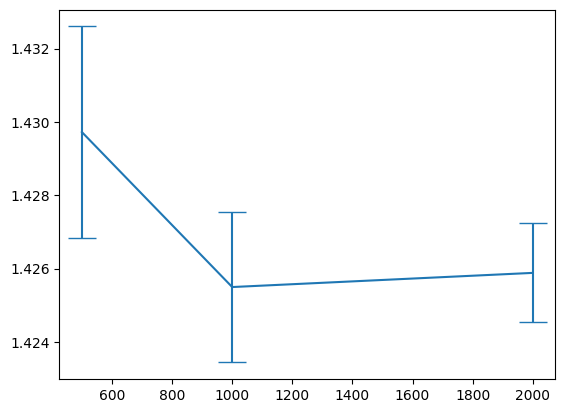

In [65]:
print(particles)
print(k_values)
plt.errorbar(particles, k_values, yerr=err_values, capsize=10)

plt.show()

## Tallies

In this section, we'll be looking at how to extract custom information from an OpenMC simulation in what is known as a "tally." A tally accumulates statistical information during the simulation about particles when they eneter regions of phase space specified on the tally. The limits of these regions are set by "filters" applied to the tally. Scores and nuclides can also be applied to tallies to indicate what type of information is kept about the particle (e.g. reaction types, flux, heat, etc.).

Any tally in OpenMC can be described with the following form:

$$ 
 X = \underbrace{\int d\mathbf{r} \int d\mathbf{\Omega} \int
    dE}_{\text{filters}} \underbrace{f(\mathbf{r}, \mathbf{\Omega},
    E)}_{\text{scores}} \underbrace{\psi (\mathbf{r}, \mathbf{\Omega}, E)}_{\text{angular flux}}
$$

where filters set the limits of the integrals and the scoring function is convolved with particle information (e.g. reaction type, current material, etc.). For example, if you wanted to calculate the fission reaction rate caused by fast neutrons in cell 3, your tally becomes

$$ 
 X = \int_\text{cell 3} d\mathbf{r} \int_{4\pi} d\mathbf{\Omega} \int_{1 MeV}^{20 MeV}
    dE \ \ \Sigma_f(\mathbf{r}, \mathbf{\Omega},
    E) \psi (\mathbf{r}, \mathbf{\Omega}, E)
$$

<div class="alert alert-block alert-info">
A full list of scores and their meanings can be found <a href=https://docs.openmc.org/en/stable/usersguide/tallies.html#scores >here</a>.
</div>

### Mesh Tallies

Let's plot the power distribution as a function of space using a structured mesh tally.

In [66]:
mesh = openmc.RegularMesh()
mesh.lower_left = (-pitch/2, -pitch/2)
mesh.upper_right = (pitch/2, pitch/2)
mesh.dimension = (50, 50)

heat = openmc.Tally()
mesh_filter = openmc.MeshFilter(mesh)
heat.scores = ['kappa-fission']
heat.filters = [mesh_filter]
model.tallies = [heat]

In [67]:
statepoint = model.run()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

      202/1    1.39695    1.40229 +/- 0.00534
      203/1    1.42667    1.41042 +/- 0.00869
      204/1    1.49596    1.43180 +/- 0.02225
      205/1    1.44183    1.43381 +/- 0.01735
      206/1    1.44076    1.43497 +/- 0.01422
      207/1    1.46521    1.43929 +/- 0.01277
      208/1    1.41488    1.43624 +/- 0.01147
      209/1    1.40947    1.43326 +/- 0.01054
      210/1    1.42311    1.43225 +/- 0.00948
      211/1    1.42040    1.43117 +/- 0.00865
      212/1    1.35919    1.42517 +/- 0.00991
      213/1    1.37734    1.42149 +/- 0.00983
      214/1    1.48451    1.42599 +/- 0.01016
      215/1    1.45353    1.42783 +/- 0.00963
      216/1    1.42072    1.42738 +/- 0.00902
      217/1    1.35509    1.42313 +/- 0.00948
      218/1    1.49938    1.42737 +/- 0.00989
      219/1    1.44800    1.42845 +/- 0.00942
      220/1    1.42177    1.42812 +/- 0.00894
      221/1    1.48722    1.43093 +/- 0.00896
      222/1    1.45372    1.43197 +/- 0.00860
      223/1    1.41445    1.43121 

      382/1    1.41459    1.42349 +/- 0.00285
      383/1    1.43769    1.42356 +/- 0.00283
      384/1    1.43039    1.42360 +/- 0.00282
      385/1    1.47017    1.42385 +/- 0.00281
      386/1    1.39280    1.42369 +/- 0.00280
      387/1    1.40012    1.42356 +/- 0.00279
      388/1    1.43476    1.42362 +/- 0.00277
      389/1    1.45098    1.42376 +/- 0.00276
      390/1    1.36630    1.42346 +/- 0.00277
      391/1    1.38331    1.42325 +/- 0.00276
      392/1    1.46126    1.42345 +/- 0.00275
      393/1    1.49842    1.42384 +/- 0.00277
      394/1    1.37463    1.42358 +/- 0.00276
      395/1    1.44404    1.42369 +/- 0.00275
      396/1    1.37570    1.42344 +/- 0.00275
      397/1    1.42722    1.42346 +/- 0.00273
      398/1    1.45764    1.42364 +/- 0.00273
      399/1    1.48668    1.42395 +/- 0.00273
      400/1    1.45182    1.42409 +/- 0.00272
 Creating state point statepoint.400.h5...

 =======================>     TIMING STATISTICS     <=======================

 Tot

In [68]:
with openmc.StatePoint(statepoint) as sp:
    mesh_tally_out = sp.get_tally(id=heat.id)
    
mesh_flux = mesh_tally_out.get_values()
mesh_flux = mesh_flux.reshape(mesh.dimension)

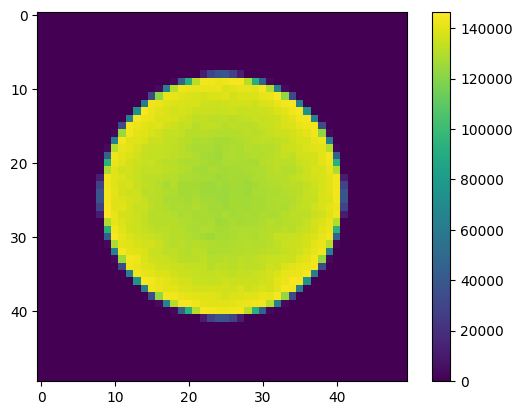

In [69]:
plt.figure()
img = plt.imshow(mesh_flux)
plt.colorbar(img)